# ARTI404 — Image Processing
## Lab 3 — Image Manipulations using OpenCV Library

**Session 3 · Image Manipulations using OpenCV Library**
Basic OpenCV image I/O and color-space conversions, followed by geometric transformations (resize, rotate, shear) and intensity transformations (negative, log, power-law) on a digital image.

| | |
|---|---|
| **Duration** | 150 minutes |
| **Outcome** | Explain how digital images are represented and manipulated in a computer, and apply geometric transformations to images |
| **Tools** | Python 3, Jupyter; Libraries: OpenCV |

---

### How to work through the notebook

* The lab has two stages: **Part 1 — OpenCV Basics** (reading, saving, and converting images), then **Task 1 — Geometric Transformations** and **Task 2 — Intensity Transformations**.
* Run the cells **in order**, top to bottom — every task reuses `img` / `gray_img` defined in Part 1.
* Part 1 onward needs an image file that is **not included** in this notebook — see the note right below for exactly where to place it.
* Short **Observations** follow each task, and a short **Conclusion** closes the notebook.

---

### By the end of this lab you should be able to

1. Read, display, save, and check the datatype of an image with OpenCV.
2. Convert an image between color spaces (BGR to Grayscale, BGR to YUV) and view individual channels.
3. Apply geometric transformations: resizing, rotation, and shear.
4. Apply intensity transformations: negative, log, and power-law (gamma), and explain their effect on contrast.

> **Before running the cells below:** save this notebook inside its own `Lab#3` folder, and create an `images` folder next to it containing the lab's picture as `images/input.jpg` (so the full path is `Lab#3/images/input.jpg`, matching `./images/input.jpg` from the notebook's own point of view).
>
> No image was provided with this lab, so **this notebook has not been run against a real picture** — the image-dependent cells below are written to be correct and ready to run once `input.jpg` is in place. If your file has a different name, only the `image_path` variable below needs to change.

---
## Setup

Run this cell first. It imports every library used in this lab and confirms they are installed.

In [5]:
# If a library below is missing, install it first (uncomment as needed):
# !pip install opencv-python numpy matplotlib

import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("OpenCV     :", cv2.__version__)
print("NumPy      :", np.__version__)
print("Matplotlib :", matplotlib.__version__)

print("\nSetup OK")

OpenCV     : 5.0.0
NumPy      : 2.5.3
Matplotlib : 3.11.2

Setup OK


---
## Part 1 — OpenCV Basics

`cv2.imshow` / `cv2.waitKey` (as shown in the manual) open a native OS window and do not display inline in a notebook, so every step below uses `plt.imshow` instead to show results directly here. OpenCV also loads color images in **BGR** order, so color images are converted to RGB before being handed to Matplotlib.

### Step #1 — Read an image and check its datatype

`cv2.imread` loads the image as a NumPy array in BGR order.

Type      : <class 'numpy.ndarray'>
Datatype  : uint8
Shape     : (256, 256, 3)


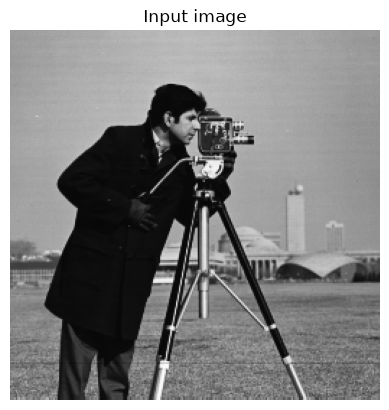

In [6]:
image_path = '../images/cameraman.tif' # change this if your image has a different name

img = cv2.imread(image_path)

if img is None:
    print(f"Error: unable to load image at {image_path}")

print("Type      :", type(img))
print("Datatype  :", img.dtype)
print("Shape     :", img.shape)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Input image')
plt.axis('off')
plt.show()

### Step #2 — Load the image in grayscale

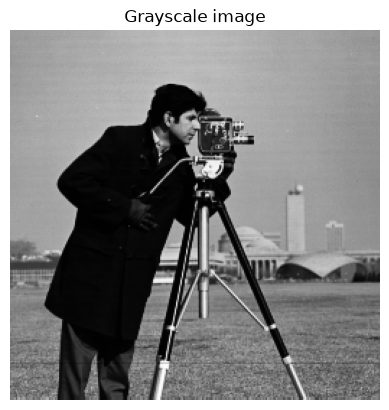

In [7]:
gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale image')
plt.axis('off')
plt.show()

### Step #3 — Save an image

In [8]:
cv2.imwrite('./images/output.jpg', gray_img)

False

### Step #4 — Convert to different color spaces

`img` is converted to grayscale again (this time with `cv2.cvtColor`) and to YUV, and the YUV image's Y, U, and V channels are displayed separately.

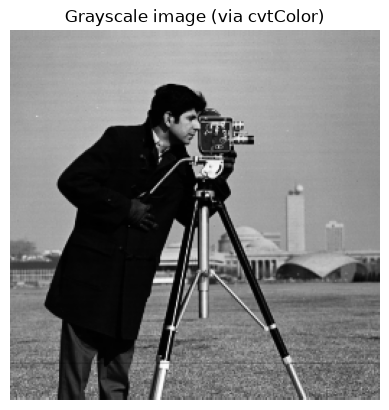

In [9]:
gray_img2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_img2, cmap='gray')
plt.title('Grayscale image (via cvtColor)')
plt.axis('off')
plt.show()

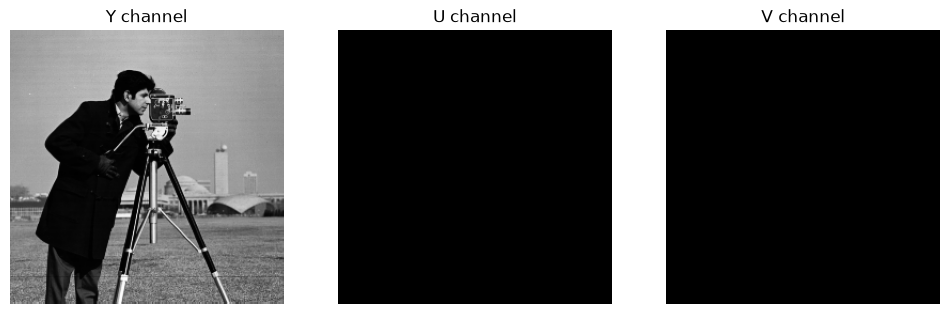

In [10]:
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(yuv_img[:, :, 0], cmap='gray')
plt.title('Y channel')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(yuv_img[:, :, 1], cmap='gray')
plt.title('U channel')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(yuv_img[:, :, 2], cmap='gray')
plt.title('V channel')
plt.axis('off')
plt.show()

---
## Task #1 — Geometric Transformations

**1. Increase the size of the image**

The image is resized to 1.5x its original width and height using `cv2.resize`.

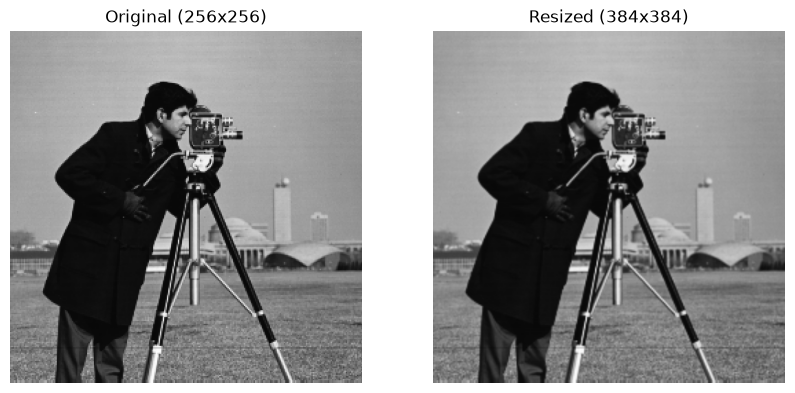

In [11]:
h, w = img.shape[:2]
scale = 1.5
resized_img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Original ({w}x{h})')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Resized ({resized_img.shape[1]}x{resized_img.shape[0]})')
axes[1].axis('off')
plt.show()

**2. Rotate the image by 120 degrees**

Rotating onto a fixed, same-size canvas would crop the corners of the rotated image, since a rotated rectangle needs a larger bounding box to fit. The canvas size below is computed from the rotation angle so the entire rotated image is kept.

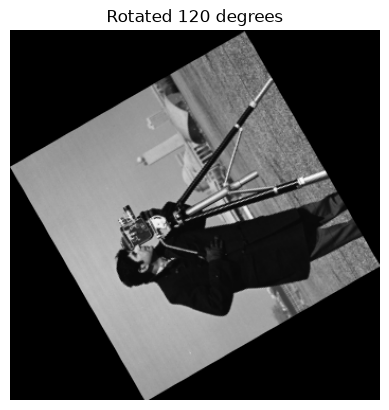

In [12]:
angle = 120
center = (w // 2, h // 2)
M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)

# Compute the new canvas size so the rotated image is not cropped
cos = np.abs(M_rot[0, 0])
sin = np.abs(M_rot[0, 1])
new_w = int((h * sin) + (w * cos))
new_h = int((h * cos) + (w * sin))

# Shift the rotation matrix so the rotated image is centered in the new canvas
M_rot[0, 2] += (new_w / 2) - center[0]
M_rot[1, 2] += (new_h / 2) - center[1]

rotated_img = cv2.warpAffine(img, M_rot, (new_w, new_h))

plt.imshow(cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB))
plt.title('Rotated 120 degrees')
plt.axis('off')
plt.show()

**3. Shear transformation**

A shear transformation slants an image: every row is shifted sideways by an amount proportional to its distance from the top, so vertical lines become diagonal (like tilting a stack of cards). It is implemented as an affine transform with an off-diagonal term in the matrix.

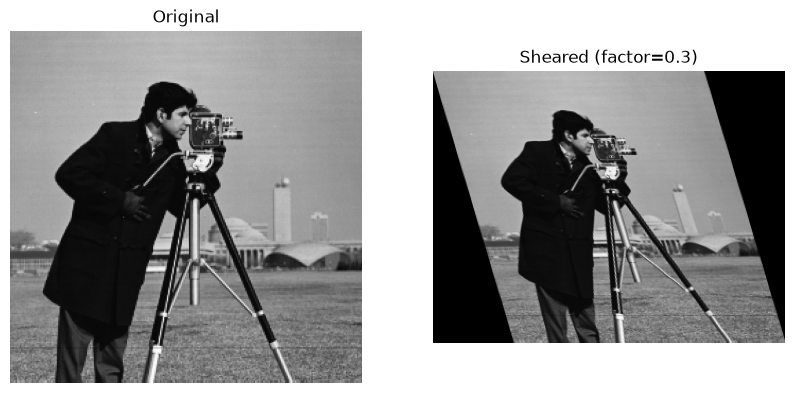

In [13]:
shear_factor = 0.3
M_shear = np.float32([[1, shear_factor, 0],
                       [0, 1, 0]])

# Widen the canvas so the sheared content is not cut off on the right
sheared_w = int(w + shear_factor * h)
sheared_img = cv2.warpAffine(img, M_shear, (sheared_w, h))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Sheared (factor={shear_factor})')
axes[1].axis('off')
plt.show()

**Observations:** resizing changes the image's scale without altering its content. The 120-degree rotation, combined with the enlarged canvas, keeps every corner of the original image inside the frame instead of cutting it off. The shear keeps the top row fixed and pushes each lower row sideways by more and more, turning rectangles into parallelograms.

---
## Task #2 — Intensity Transformations

The transformations below operate on `gray_img` (the grayscale image from Part 1).

**1. Negative image**

For an 8-bit grayscale image (values 0-255), the negative simply flips every pixel: `s = 255 - r`.

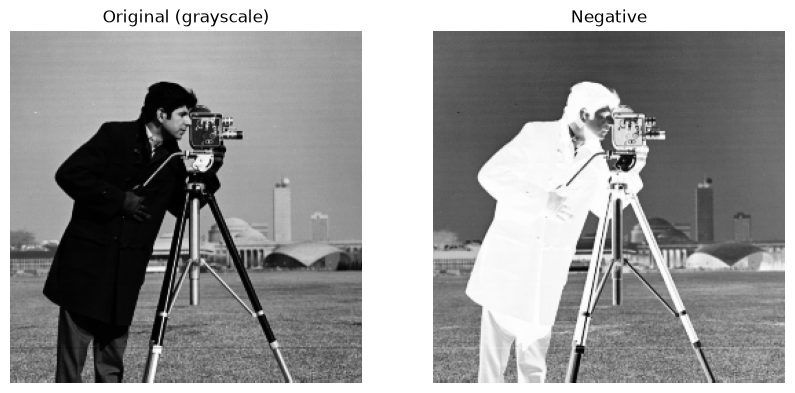

In [14]:
negative_img = 255 - gray_img

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original (grayscale)')
axes[0].axis('off')
axes[1].imshow(negative_img, cmap='gray')
axes[1].set_title('Negative')
axes[1].axis('off')
plt.show()

**2. Log transformation**

The log transform `s = c * log(1 + r)` compresses the wide range of bright pixel values while stretching out the narrow range of dark ones, brightening shadow detail. The constant `c` is chosen from the image's own maximum pixel value so the output still fills the full `[0, 255]` range.

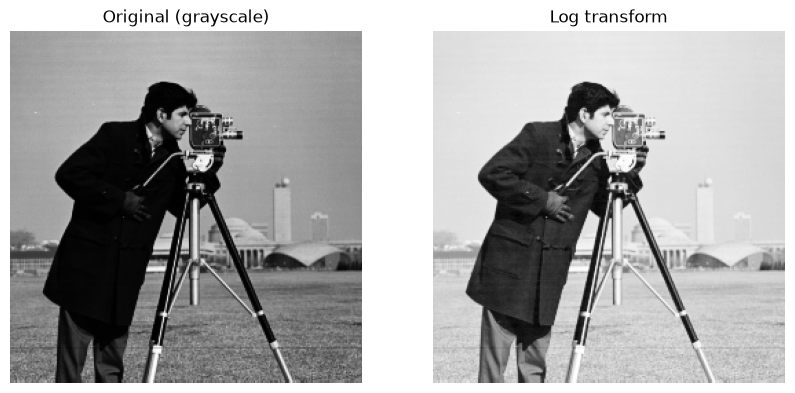

In [15]:
gray_float = gray_img.astype(np.float64)
c = 255 / np.log(1 + np.max(gray_float))
log_img = c * np.log(1 + gray_float)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original (grayscale)')
axes[0].axis('off')
axes[1].imshow(log_img, cmap='gray')
axes[1].set_title('Log transform')
axes[1].axis('off')
plt.show()

**3. Power-law (gamma) transformation**

The power-law transform `s = c * r^gamma` (with `r` normalized to `[0, 1]`) increases contrast differently depending on `gamma`: values below 1 stretch out the dark end of the range (spreading shadow detail across more output levels), while values above 1 stretch out the bright end instead. A `gamma` of **0.4** is used here to increase contrast in the darker tones — a common choice when shadow detail is compressed together near black. The best value in practice depends on the image's own histogram, so inspect the result and adjust `gamma` if needed.

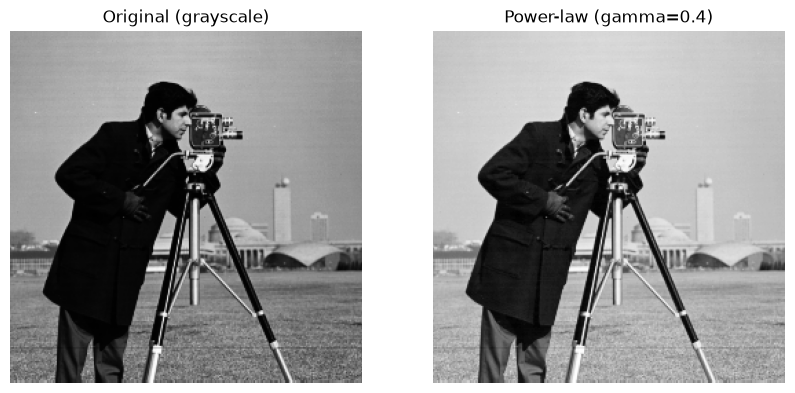

In [16]:
gamma = 0.4
normalized = gray_img.astype(np.float64) / 255.0
power_law_img = np.power(normalized, gamma) * 255.0
power_law_img = np.clip(power_law_img, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original (grayscale)')
axes[0].axis('off')
axes[1].imshow(power_law_img, cmap='gray')
axes[1].set_title(f'Power-law (gamma={gamma})')
axes[1].axis('off')
plt.show()

**Observations:** the negative reverses the tonal scale, so the darkest and brightest regions swap. The log transform pulls the whole image toward the bright end, which is most useful when important detail is hiding in dark shadows. Because `gamma < 1` was used, the power-law transform has a similar brightening effect to the log transform, but its curve shape can be tuned exactly through `gamma` rather than being fixed to a logarithm.

---
## Conclusion

This lab covered the basics of reading, displaying, saving, and color-converting images with OpenCV, then applied two families of transformations: **geometric** (resize, rotate, shear), which move pixels to new positions, and **intensity** (negative, log, power-law), which remap pixel *values* without moving them. Together they cover the two fundamental ways a digital image can be manipulated.

---

### Resources

* [Image Transformations using OpenCV in Python (GeeksforGeeks)](https://www.geeksforgeeks.org/image-transformations-using-opencv-in-python/)
* [Image Transformations using OpenCV in Python (thepythoncode.com)](https://www.thepythoncode.com/article/image-transformations-using-opencv-in-python)
* [Basic Intensity Transformation Functions (Medium)](https://medium.com/@khanhson0811/basic-intensity-transformation-functions-and-example-with-opencv-1a56932f34ac)

**End of notebook.**